In [17]:
from __future__ import annotations
import math
import jax
import jax.numpy as jnp
from flax import nnx
import numpy as np
import matplotlib.pyplot as plt
import optax
from tqdm import tqdm
from typing import Optional, Tuple
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle


# ----- FP64 everywhere
jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64


In [18]:
# --------------------------
# Chebyshev–Lobatto utilities
# --------------------------
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)

def lobatto_bary_weights(K: int) -> jnp.ndarray:
    # w_j = (-1)^j * c_j,  c_0=c_K=1/2 else 1
    j = jnp.arange(K + 1, dtype=jnp.int32)
    sign = 1 - 2 * (j % 2)  # (-1)^j
    c = jnp.ones_like(sign, dtype=DTYPE)
    c = c.at[0].set(0.5).at[K].set(0.5)
    return sign.astype(DTYPE) * c

In [19]:
# --------------------------
# Signed softmax normalization
# --------------------------
def _logdiffexp(a: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    # stable log(exp(a) - exp(b)) assuming a >= b
    return a + jnp.log1p(-jnp.exp(b - a))

def signed_normalize_stable(
    logits: jnp.ndarray,      # [..., M]
    signs: jnp.ndarray,       # [..., M] in [-1, 1]
    values: jnp.ndarray,      # [..., M]
    axis: int = -1,
    return_alpha: bool = False,
) -> Tuple[jnp.ndarray, Optional[jnp.ndarray]]:
    """
    y_hat = [Σ s_j e^{logits_j} v_j] / [Σ s_j e^{logits_j}]
    computed stably by splitting into positive/negative parts with LSE.
    """
    logits = jnp.asarray(logits, dtype=DTYPE)
    signs  = jnp.asarray(signs,  dtype=DTYPE)
    values = jnp.asarray(values, dtype=DTYPE)

    m  = jnp.max(logits, axis=axis, keepdims=True)
    u  = logits - m

    s_pos = jnp.maximum(signs,  0.0)
    s_neg = jnp.maximum(-signs, 0.0)

    # Denominator: Σ s_j e^{u_j} = (Σ_pos) - (Σ_neg)
    Lp = jax.nn.logsumexp(jnp.log(s_pos + 1e-300) + u, axis=axis, keepdims=True)
    Ln = jax.nn.logsumexp(jnp.log(s_neg + 1e-300) + u, axis=axis, keepdims=True)
    a, b = jnp.maximum(Lp, Ln), jnp.minimum(Lp, Ln)
    denom_sign = jnp.where(Lp >= Ln, 1.0, -1.0)
    log_denom  = _logdiffexp(a, b)

    # Numerator: Σ (s_j v_j) e^{u_j} = (Σ_pos) - (Σ_neg)
    t = signs * values
    t_pos = jnp.maximum(t,  0.0)
    t_neg = jnp.maximum(-t, 0.0)
    Ap = jax.nn.logsumexp(jnp.log(t_pos + 1e-300) + u, axis=axis, keepdims=True)
    An = jax.nn.logsumexp(jnp.log(t_neg + 1e-300) + u, axis=axis, keepdims=True)
    a, b = jnp.maximum(Ap, An), jnp.minimum(Ap, An)
    numer_sign = jnp.where(Ap >= An, 1.0, -1.0)
    log_numer  = _logdiffexp(a, b)

    y_hat = (numer_sign * jnp.exp(log_numer)) / (denom_sign * jnp.exp(log_denom))
    y_hat = jnp.squeeze(y_hat, axis=axis)

    if return_alpha:
        alpha = (signs * jnp.exp(u)) / (denom_sign * jnp.exp(log_denom))  # diagnostic only
        return y_hat, alpha
    else:
        return y_hat, None

# --------------------------
# Smooth sign “MLP” (1-layer)
# --------------------------
class SigmaGate(nnx.Module):
    """
    σ_j(x) ≈ sign(w_j) * sign(x - ξ_j), with smooth options.
    Params:
      W_j = β, b_j = -β ξ_j
    """
    W: nnx.Param
    b: nnx.Param
    s_w: nnx.Param
    beta: DTYPE
    eps_s: DTYPE
    mode: str

    def __init__(self,
                 x_nodes: jnp.ndarray,     # [M]
                 w_signs: jnp.ndarray,     # [M] = sign(w_j)
                 beta: float = 50.0,
                 eps_s: float = 1e-6,
                 mode: str = "rational",
                 *, rngs: nnx.Rngs | None = None):
        x_nodes = jnp.asarray(x_nodes, dtype=DTYPE)
        w_signs = jnp.asarray(w_signs, dtype=DTYPE)
        self.beta  = DTYPE(beta)
        self.eps_s = DTYPE(eps_s)
        self.mode  = mode
        self.W = nnx.Param(jnp.full_like(x_nodes, self.beta))
        self.b = nnx.Param(-self.beta * x_nodes)
        self.s_w = nnx.Param(w_signs)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        z = self.W[None, ...] * x[..., None] + self.b[None, ...]  # z_j(x) = β(x-ξ_j)
        if self.mode == "tanh":
            s = jnp.tanh(z)
        elif self.mode == "logistic":
            s = 2.0 * jax.nn.sigmoid(z) - 1.0
        elif self.mode == "rational":
            dz = z / self.beta
            s  = dz / jnp.sqrt(dz*dz + self.eps_s*self.eps_s)
        else:
            raise ValueError(f"Unknown mode {self.mode}")
        return self.s_w[None, ...] * s

# --------------------------
# Fixed log-kernel “softmax”
# --------------------------
class FixedLogKernelSoftmax(nnx.Module):
    """
    logits_j(x) = -τ log(|x - ξ_j| + δ) + β_j
    If τ=1 and β_j = log|w_j|, then with SigmaGate signs, the signed-normalizer
    recovers the **second barycentric formula** exactly (with node branch)【turn1file6†L52-L70】.
    """
    xi: nnx.Param        # [M] (trainable nodes if desired)
    beta: nnx.Param      # [M] (log-magnitude offsets)
    y: nnx.Param         # [M] (data values)
    tau: nnx.Param
    delta: DTYPE

    def __init__(self,
                 x_nodes: jnp.ndarray,     # [M]
                 yvals:  jnp.ndarray,      # [M]
                 beta:   Optional[jnp.ndarray] = None,  # default zeros or log|w|
                 tau: float = 1.0,
                 delta: float = 1e-18,
                 *, rngs: nnx.Rngs | None = None):
        x_nodes = jnp.asarray(x_nodes, dtype=DTYPE)
        yvals  = jnp.asarray(yvals,  dtype=DTYPE)
        self.xi   = nnx.Param(x_nodes)
        if beta is None:
            self.beta = nnx.Param(jnp.zeros_like(x_nodes))
        else:
            self.beta = nnx.Param(jnp.asarray(beta, dtype=DTYPE))
        self.y     = nnx.Param(yvals)
        self.tau   = nnx.Param(tau)
        self.delta = DTYPE(delta)

    def logits(self, x: jnp.ndarray) -> jnp.ndarray:
        d = jnp.abs(x[..., None] - self.xi[None, ...]) + self.delta  # [..., M]
        return -self.tau * jnp.log(d) + self.beta[None, ...]

    def __call__(self, x: jnp.ndarray):
        # Optional “unsigned” softmax head (useful for debugging)
        logits = self.logits(x)
        alpha  = jax.nn.softmax(logits, axis=-1)
        y_hat  = jnp.einsum('...m,m->...', alpha, self.y)
        return y_hat, alpha

# --------------------------
# Signed soft-barycentric head
# --------------------------
class SignedLogKernelSoftmax(nnx.Module):
    """
    Wraps FixedLogKernelSoftmax + SigmaGate to produce the signed ratio.
    Handles the exact-node branch per Berrut–Trefethen【turn1file1†L11-L21】.
    """
    fixedlog: FixedLogKernelSoftmax
    sigmagate: Optional[SigmaGate]
    node_atol: DTYPE

    def __init__(self,
                 fixedlog: FixedLogKernelSoftmax,
                 sigmagate: Optional[SigmaGate] = None,
                 node_atol: float = 1e-18,
                 *, rngs: nnx.Rngs | None = None):
        self.fixedlog  = fixedlog
        self.sigmagate = sigmagate
        self.node_atol = DTYPE(node_atol)

    def __call__(self, x: jnp.ndarray):
        logits = self.fixedlog.logits(x)                          # [..., M]
        signs  = (self.sigmagate(x) if self.sigmagate is not None
                  else jnp.ones_like(logits, dtype=DTYPE))        # [..., M]

        # Signed normalization
        y_hat, alpha = signed_normalize_stable(
            logits, signs, values=self.fixedlog.y, axis=-1, return_alpha=True
        )

        # # Exact-node replacement rule (x == ξ_k ⇒ return y_k)【turn1file1†L11-L21】.
        # xi = self.fixedlog.xi
        # d  = jnp.abs(x[..., None] - xi[None, ...])
        # at_node = (d <= self.node_atol).any(axis=-1)

        # def pick_exact(x_row):
        #     k = jnp.argmin(jnp.abs(x_row - xi))
        #     return self.fixedlog.y[k]

        # if at_node.ndim == 0:
        #     y_exact = pick_exact(x)
        #     y_hat   = jnp.where(at_node, y_exact, y_hat)
        # else:
        #     y_exact = jax.vmap(pick_exact)(x)
        #     y_hat   = jnp.where(at_node, y_exact, y_hat)

        return y_hat


In [20]:
# Given data (x_j, y_j) on Chebyshev–Lobatto nodes:
M   = 4097
xi0 = cheb_lobatto_nodes(M-1)               # ξ_j
w0  = lobatto_bary_weights(M-1)             # barycentric weights (signed)
y0  = jnp.sin(2*jnp.pi*xi0)                 # for example

# Soft-barycentric init that reproduces the exact rational formula:
tau   = 1.0
beta0 = jnp.log(jnp.abs(w0))       # β_j = log|w_j|
gate  = SigmaGate(x_nodes=xi0, w_signs=jnp.sign(w0), beta=50.0, mode="rational")
core  = FixedLogKernelSoftmax(x_nodes=xi0, yvals=y0, beta=beta0, tau=tau, delta=1e-14)
model = SignedLogKernelSoftmax(core, gate, node_atol=1e-18)

# Then you can treat (core.xi, core.beta) as trainable to move nodes / magnitudes,
# and (gate.W, gate.b) if you want the sign gate sharpness to adapt.

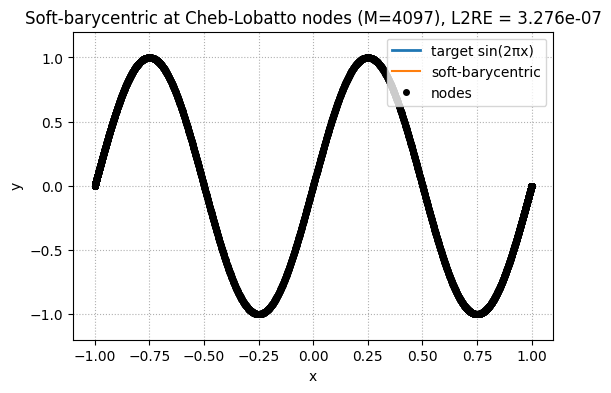

In [21]:
x = jnp.linspace(-1.0, 1.0, 20000, dtype=DTYPE)
y_true = jnp.sin(2*jnp.pi*x)
y_hat = model(x)

plt.figure(figsize=(6.2, 4.0))
plt.plot(x, y_true, lw=2, label='target sin(2πx)')
plt.plot(x, np.array(y_hat), lw=1.5, label='soft-barycentric')
plt.plot(xi0, y0, 'ko', ms=4, label='nodes')
plt.ylim(-1.2, 1.2)
plt.title(f'Soft-barycentric at Cheb-Lobatto nodes (M={M}), L2RE = {float(jnp.linalg.norm(y_hat - y_true)/jnp.linalg.norm(y_true)):.3e}')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True, ls=':')
plt.show()

In [41]:
def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * jnp.pi * DTYPE(k) * x)

# =============== ε sweep for initialization ===============
def loss_fn(model: SignedLogKernelSoftmax, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)


def run_experiment_broyden(
    M: int = 65,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),
    # logging
    log_every: int = 1,
):
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    w0 = lobatto_bary_weights(M)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    tau   = 1.0
    beta0 = jnp.log(jnp.abs(w0))       # β_j = log|w_j|
    gate  = SigmaGate(x_nodes=xs_cheb, w_signs=jnp.sign(w0), beta=100.0, mode="rational")
    core  = FixedLogKernelSoftmax(x_nodes=xs_cheb, yvals=ys_cheb, beta=beta0, tau=tau, delta=1e-14)
    model = SignedLogKernelSoftmax(core, gate, node_atol=1e-18)

    # Create a deep copy of the initial model for comparison
    # We need to preserve the initial state before any training
    initial_graphdef, initial_state = nnx.split(model)
    initial_model = nnx.merge(initial_graphdef, initial_state)  # This creates a copy

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))


    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)                 # base_state is the full FlatState (Params + Variables)
    base_state = nnx.freeze(nnx.pure(base_state))           # make it a pure arrays pytree for JIT-friendliness
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # Training history tracking
    train_losses = []
    eval_errors = []
    step_indices = []

    # training loop
    pbar = tqdm(range(steps), desc="training")
    for i in pbar:
        
        loss = train_step_b(model, optim, x_train, y_train)
        if i % log_every == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            # Store metrics for plotting
            train_losses.append(float(loss))
            eval_errors.append(float(eval_error))
            step_indices.append(i)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")


    
    # Store final metrics
    final_loss = train_step_b(model, optim, x_train, y_train)
    final_eval_error = rel_l2_error(model, x_eval, y_eval)
    train_losses.append(float(final_loss))
    eval_errors.append(float(final_eval_error))
    step_indices.append(steps)
    
    # Convert to arrays for easier plotting
    train_losses = jnp.array(train_losses)
    eval_errors = jnp.array(eval_errors)
    step_indices = jnp.array(step_indices)
    
    return initial_model, model, {
        'train_losses': train_losses,
        'eval_errors': eval_errors,
        'step_indices': step_indices,
        'final_train_loss': float(final_loss),
        'final_eval_error': float(final_eval_error)
    }

In [42]:
def compare_models(initial_model, trained_model, x_eval, y_eval, title_suffix=""):
    """Compare initial vs trained model performance and parameters."""
    
    # Evaluate both models
    y_initial = initial_model(x_eval)
    y_trained = trained_model(x_eval)
    
    initial_error = rel_l2_error(initial_model, x_eval, y_eval)
    trained_error = rel_l2_error(trained_model, x_eval, y_eval)
    
    print(f"Model Comparison{title_suffix}:")
    print(f"Initial model rel L2 error: {initial_error:.6e}")
    print(f"Trained model rel L2 error: {trained_error:.6e}")
    print(f"Improvement factor: {initial_error / trained_error:.2f}x")
    
    # Create subplot layout: predictions + FixedLogKernelSoftmax + SigmaGate
    fig = plt.figure(figsize=(18, 5))
    ax1 = plt.subplot(1, 3, 1)
    ax2 = plt.subplot(1, 3, 2) 
    ax3 = plt.subplot(1, 3, 3)
    
    # Left plot: Model predictions
    ax1.plot(x_eval, y_eval, 'k-', linewidth=2, label='True function', alpha=0.8)
    ax1.plot(x_eval, y_initial, 'b--', linewidth=2, label=f'Initial (rel L2: {initial_error:.2e})', alpha=0.7)
    ax1.plot(x_eval, y_trained, 'r-', linewidth=2, label=f'Trained (rel L2: {trained_error:.2e})', alpha=0.8)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(f'Model Predictions{title_suffix}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Middle plot: FixedLogKernelSoftmax parameter changes
    xi_initial = initial_model.fixedlog.xi.value
    xi_trained = trained_model.fixedlog.xi.value
    beta_initial = initial_model.fixedlog.beta.value
    beta_trained = trained_model.fixedlog.beta.value
    tau_initial = initial_model.fixedlog.tau.value
    tau_trained = trained_model.fixedlog.tau.value
    
    xi_change = jnp.linalg.norm(xi_trained - xi_initial)
    beta_change = jnp.linalg.norm(beta_trained - beta_initial)
    tau_change = abs(tau_trained - tau_initial)
    
    fixed_param_names = ['Node pos. (ξ)', 'Beta coeff.', 'Tau param']
    fixed_param_changes = [float(xi_change), float(beta_change), float(tau_change)]
    fixed_colors = ['blue', 'green', 'orange']
    
    ax2.bar(fixed_param_names, fixed_param_changes, color=fixed_colors)
    ax2.set_ylabel('L2 Norm of Change')
    ax2.set_title(f'FixedLogKernelSoftmax Changes{title_suffix}')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Right plot: SigmaGate parameter changes
    W_initial = initial_model.sigmagate.W.value
    W_trained = trained_model.sigmagate.W.value
    b_initial = initial_model.sigmagate.b.value
    b_trained = trained_model.sigmagate.b.value
    s_w_initial = initial_model.sigmagate.s_w.value
    s_w_trained = trained_model.sigmagate.s_w.value
    
    W_change = jnp.linalg.norm(W_trained - W_initial)
    b_change = jnp.linalg.norm(b_trained - b_initial)
    s_w_change = jnp.linalg.norm(s_w_trained - s_w_initial)
    
    sigma_param_names = ['W (weights)', 'b (biases)', 's_w (signs)']
    sigma_param_changes = [float(W_change), float(b_change), float(s_w_change)]
    sigma_colors = ['purple', 'red', 'brown']
    
    ax3.bar(sigma_param_names, sigma_param_changes, color=sigma_colors)
    ax3.set_ylabel('L2 Norm of Change')
    ax3.set_title(f'SigmaGate Changes{title_suffix}')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed parameter statistics
    print(f"\nParameter Change Statistics:")
    print(f"FixedLogKernelSoftmax parameters:")
    print(f"  Node positions (ξ) - L2 change: {xi_change:.6e}")
    print(f"  Beta coefficients - L2 change: {beta_change:.6e}")
    print(f"  Tau parameter - Change: {tau_change:.6e}")
    print(f"  Initial tau: {float(tau_initial):.6f}, Final tau: {float(tau_trained):.6f}")
    
    print(f"\nSigmaGate parameters:")
    print(f"  W parameters - L2 change: {W_change:.6e}")
    print(f"  b parameters - L2 change: {b_change:.6e}")
    print(f"  s_w parameters - L2 change: {s_w_change:.6e}")
    
    # Additional SigmaGate analysis
    print(f"\nSigmaGate detailed analysis:")
    print(f"  W range: initial [{float(jnp.min(W_initial)):.3f}, {float(jnp.max(W_initial)):.3f}], "
          f"final [{float(jnp.min(W_trained)):.3f}, {float(jnp.max(W_trained)):.3f}]")
    print(f"  b range: initial [{float(jnp.min(b_initial)):.3f}, {float(jnp.max(b_initial)):.3f}], "
          f"final [{float(jnp.min(b_trained)):.3f}, {float(jnp.max(b_trained)):.3f}]")
    print(f"  s_w range: initial [{float(jnp.min(s_w_initial)):.3f}, {float(jnp.max(s_w_initial)):.3f}], "
          f"final [{float(jnp.min(s_w_trained)):.3f}, {float(jnp.max(s_w_trained)):.3f}]")

# Example: Run experiment and compare models
print("Running SSBroyden experiment with model comparison...")
initial_model, trained_model, history = run_experiment_broyden(
    M=65, k=2, node_type="cheb",
    steps=100, n_train=4000, n_eval=20000, log_every=10
)

Running SSBroyden experiment with model comparison...


step 90, train loss=3.627e-16, eval rel L2=3.894e-08: 100%|██████████| 100/100 [00:02<00:00, 38.60it/s]


Model Comparison (SSBroyden):
Initial model rel L2 error: 1.261766e-04
Trained model rel L2 error: 3.894591e-08
Improvement factor: 3239.79x


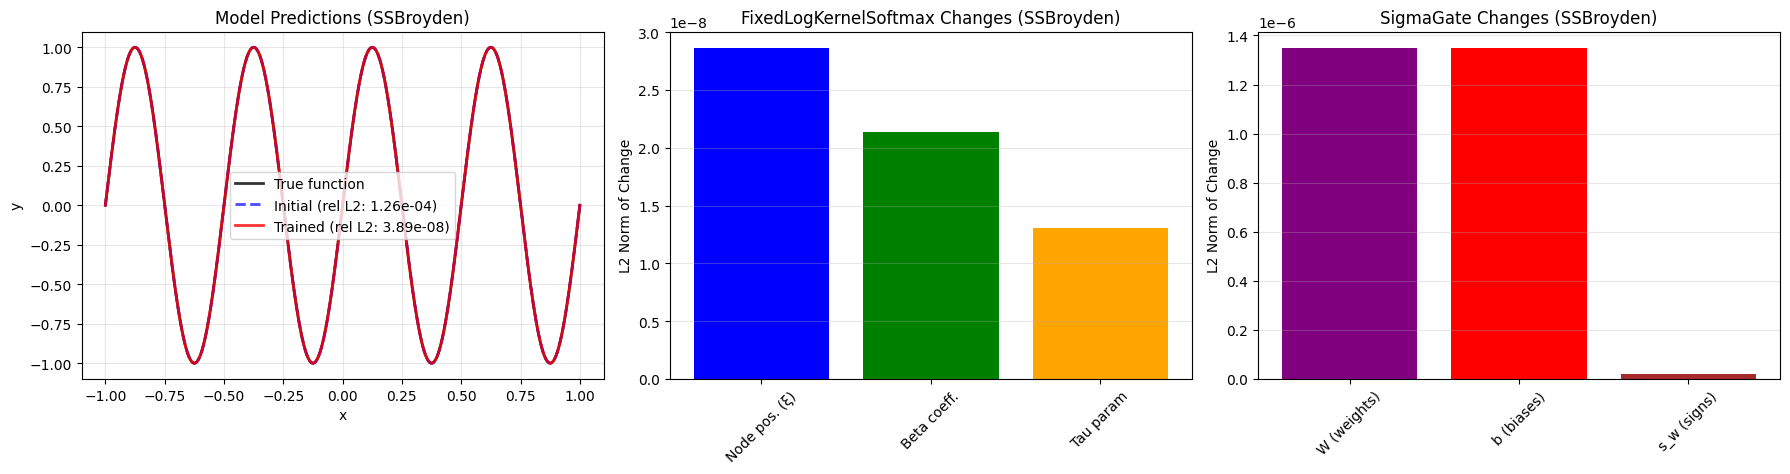


Parameter Change Statistics:
FixedLogKernelSoftmax parameters:
  Node positions (ξ) - L2 change: 2.863922e-08
  Beta coefficients - L2 change: 2.139350e-08
  Tau parameter - Change: 1.308964e-08
  Initial tau: 1.000000, Final tau: 1.000000

SigmaGate parameters:
  W parameters - L2 change: 1.348729e-06
  b parameters - L2 change: 1.348731e-06
  s_w parameters - L2 change: 2.139356e-08

SigmaGate detailed analysis:
  W range: initial [100.000, 100.000], final [100.000, 100.000]
  b range: initial [-100.000, 100.000], final [-100.000, 100.000]
  s_w range: initial [-1.000, 1.000], final [-1.000, 1.000]


In [36]:
# Compare initial vs trained models
x_eval = jnp.linspace(-1.0, 1.0, 20000, dtype=DTYPE)
y_eval = f_sin(x_eval, k=2)  # Use same k as in the experiment
compare_models(initial_model, trained_model, x_eval, y_eval, " (SSBroyden)")

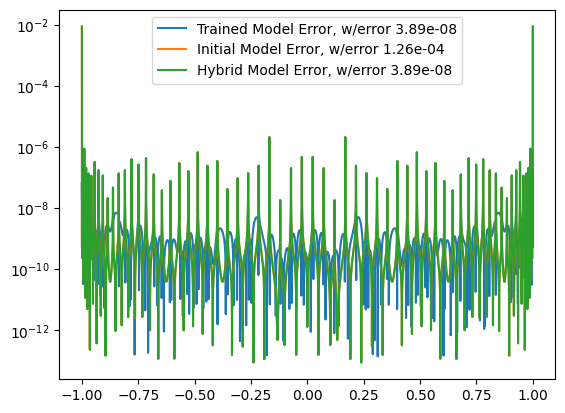

In [ ]:
plt.semilogy(x_eval, np.abs(trained_model(x_eval) - y_eval), label=f'Trained Model Error, w/error {jnp.linalg.norm(trained_model(x_eval)-y_eval)/jnp.linalg.norm(y_eval):.2e}')
plt.semilogy(x_eval, np.abs(initial_model(x_eval) - y_eval), label=f'Initial Model Error, w/error {jnp.linalg.norm(initial_model(x_eval)-y_eval)/jnp.linalg.norm(y_eval):.2e}')
plt.semilogy(x_eval, np.abs(SignedLogKernelSoftmax(fixedlog = trained_model.fixedlog, sigmagate = trained_model.sigmagate)(x_eval) - y_eval), label=f'Hybrid Model Error, w/error {jnp.linalg.norm(SignedLogKernelSoftmax(fixedlog = trained_model.fixedlog, sigmagate = trained_model.sigmagate)(x_eval) - y_eval)/jnp.linalg.norm(y_eval):.2e}')
plt.legend()


In [ ]:
graphdef, state = nnx.split(trained_model.sigmagate)
sigma_model_trained = nnx.

State({
  'fixedlog': {
    'beta': Param( # 66 (528 B)
      value=Array([-6.93147182e-01,  3.53143964e-09, -3.08289549e-09,  2.35921854e-09,
             -1.39786186e-09,  2.53493962e-10,  1.00064852e-09, -2.27290708e-09,
              3.45620891e-09, -4.43467627e-09,  5.09499652e-09, -5.34241024e-09,
              5.12004887e-09, -4.42844171e-09,  3.34035034e-09, -2.00480984e-09,
              6.34729140e-10,  5.25076514e-10, -1.24742450e-09,  1.38115039e-09,
             -9.03040820e-10, -5.52559722e-11,  1.22127441e-09, -2.24256602e-09,
              2.78434421e-09, -2.63730576e-09,  1.79872447e-09, -4.92458978e-10,
             -8.88813213e-10,  1.90772911e-09, -2.23299715e-09,  1.76170339e-09,
             -6.64238464e-10, -6.69645076e-10,  1.76657615e-09, -2.23690664e-09,
              1.91042809e-09, -8.90269370e-10, -4.92079661e-10,  1.79911425e-09,
             -2.63809244e-09,  2.78516770e-09, -2.24313658e-09,  1.22140367e-09,
             -5.48605325e-11, -9.03956339e-10, 

Hybrid model (old gate + new kernel) rel L2 error: 1.261763e-04


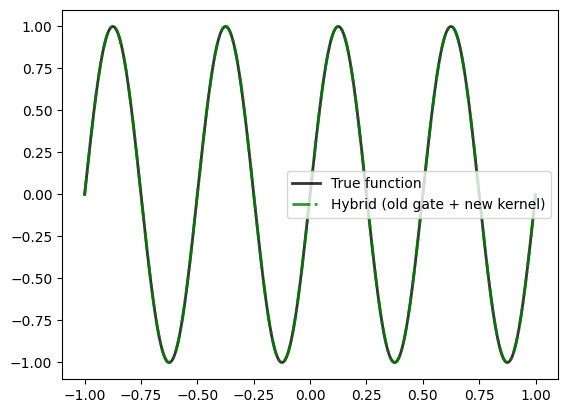

In [ ]:
def old_gate_new_kernel(init_mdl, new_mdl, x_eval, y_eval):
    """Use initial SigmaGate with new FixedLogKernelSoftmax to see effect."""
    hybrid_model = SignedLogKernelSoftmax(
        fixedlog=new_mdl.fixedlog,
        sigmagate=init_mdl.sigmagate,
        node_atol=1e-18
    )
    hybrid_error = rel_l2_error(hybrid_model, x_eval, y_eval)
    print(f"Hybrid model (old gate + new kernel) rel L2 error: {hybrid_error:.6e}")
    return hybrid_model, hybrid_error

hybrid_mdl, err = old_gate_new_kernel(initial_model, trained_model, x_eval, y_eval)

plt.plot(x_eval, y_eval, 'k-', linewidth=2, label='True function', alpha=0.8)
plt.plot(x_eval, hybrid_mdl(x_eval), 'g-.', linewidth=2, label='Hybrid (old gate + new kernel)', alpha=0.8)
plt.legend()
plt.show()

Hybrid model (old gate + new kernel) rel L2 error: 1.261763e-04


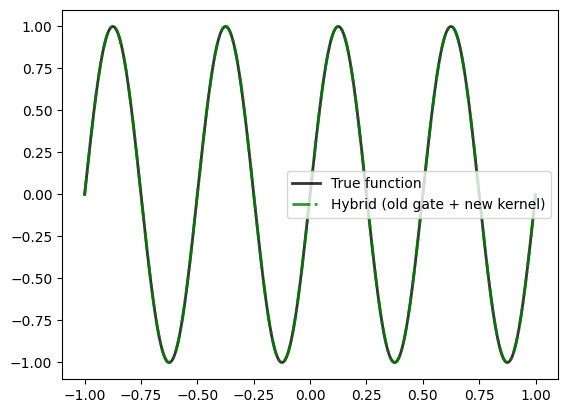

In [47]:
def old_kernel_new_gate(init_mdl, new_mdl, x_eval, y_eval):
    """Use initial SigmaGate with new FixedLogKernelSoftmax to see effect."""
    hybrid_model = SignedLogKernelSoftmax(
        fixedlog=new_mdl.fixedlog,
        sigmagate=new_mdl.sigmagate,
        node_atol=1e-18
    )
    hybrid_error = rel_l2_error(hybrid_model, x_eval, y_eval)
    print(f"Hybrid model (old kernel + new gate) rel L2 error: {hybrid_error:.6e}")
    return hybrid_model, hybrid_error
    
hybrid_mdl, err = old_gate_new_kernel(initial_model, trained_model, x_eval, y_eval)

plt.plot(x_eval, y_eval, 'k-', linewidth=2, label='True function', alpha=0.8)
plt.plot(x_eval, hybrid_mdl(x_eval), 'g-.', linewidth=2, label='Hybrid (old gate + new kernel)', alpha=0.8)
plt.legend()
plt.show()

In [28]:
trained_model.sigmagate.b 

Param( # 66 (528 B)
  value=Array([-50.00000095, -49.94161134, -49.76658174, -49.47531998,
         -49.06850631, -48.54709087, -47.91229146, -47.16559066,
         -46.30873245, -45.34371804, -44.27280128, -43.09848335,
         -41.8235069 , -40.45084972, -38.9837177 , -37.42553741,
         -35.77994804, -34.05079294, -32.24211064, -30.35812539,
         -28.40323734, -26.38201221, -24.29917066, -22.15957728,
         -19.96822918, -17.73024435, -15.45084972, -13.13536891,
         -10.78920984,  -8.41785207,  -6.02683401,  -3.62174001,
          -1.20818726,   1.20818726,   3.62174001,   6.02683401,
           8.41785207,  10.78920984,  13.13536891,  15.45084972,
          17.73024435,  19.96822918,  22.15957728,  24.29917066,
          26.38201221,  28.40323734,  30.35812539,  32.24211064,
          34.05079294,  35.77994804,  37.42553741,  38.9837177 ,
          40.45084972,  41.8235069 ,  43.09848335,  44.27280128,
          45.34371804,  46.30873245,  47.16559066,  47.91229146,

In [30]:
initial_model.sigmagate.b

Param( # 66 (528 B)
  value=Array([-50.        , -49.94161134, -49.76658174, -49.47531997,
         -49.06850631, -48.54709087, -47.91229146, -47.16559066,
         -46.30873245, -45.34371804, -44.27280128, -43.09848334,
         -41.8235069 , -40.45084972, -38.9837177 , -37.42553741,
         -35.77994804, -34.05079294, -32.24211064, -30.35812539,
         -28.40323734, -26.38201221, -24.29917066, -22.15957728,
         -19.96822918, -17.73024435, -15.45084972, -13.13536891,
         -10.78920984,  -8.41785207,  -6.02683401,  -3.62174001,
          -1.20818726,   1.20818726,   3.62174001,   6.02683401,
           8.41785207,  10.78920984,  13.13536891,  15.45084972,
          17.73024435,  19.96822918,  22.15957728,  24.29917066,
          26.38201221,  28.40323734,  30.35812539,  32.24211064,
          34.05079294,  35.77994804,  37.42553741,  38.9837177 ,
          40.45084972,  41.8235069 ,  43.09848334,  44.27280128,
          45.34371804,  46.30873245,  47.16559066,  47.91229146,

In [7]:
def run_experiment_adam(
    M: int = 65,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # training
    steps: int = 50000, 
    lr: float = 1e-3,                 # Adam learning rate
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),
    # logging
    log_every: int = 1,
):
    """
    Training function using Adam optimizer for barycentric approximation.
    Similar structure to run_experiment_broyden but with Adam instead of SSBroyden.
    """
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    w0 = lobatto_bary_weights(M)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # Initialize model with barycentric structure
    tau   = 1.0
    beta0 = jnp.log(jnp.abs(w0))       # β_j = log|w_j|
    gate  = SigmaGate(x_nodes=xs_cheb, w_signs=jnp.sign(w0), beta=50.0, mode="rational")
    core  = FixedLogKernelSoftmax(x_nodes=xs_cheb, yvals=ys_cheb, beta=beta0, tau=tau, delta=1e-14)
    model = SignedLogKernelSoftmax(core, gate, node_atol=1e-18)

    # Create Adam optimizer
    tx = optax.adam(lr)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    @nnx.jit
    def train_step_adam(model, opt, x, y):
        # Compute loss and gradients w.r.t. model parameters
        def cur_loss(m): 
            return loss_fn(m, x, y)
        
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)
        
        # Update parameters using Adam
        opt.update(model, grads)
        return f_k

    # Training history tracking
    train_losses = []
    eval_errors = []
    step_indices = []

    # training loop
    pbar = tqdm(range(steps), desc="training")
    for i in pbar:

        loss = train_step_adam(model, optim, x_train, y_train)
        if i % log_every == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            # Store metrics for plotting
            eval_errors.append(float(eval_error))
            train_losses.append(float(loss))
            step_indices.append(i)
            pbar.set_description(f"step {i}, train losses = {loss:.3e}, eval rel L2={eval_error:.3e}")

    
    # Store final metrics
    final_loss = train_step_adam(model, optim, x_train, y_train)
    final_eval_error = rel_l2_error(model, x_eval, y_eval)
    train_losses.append(float(final_loss))
    eval_errors.append(float(final_eval_error))
    step_indices.append(steps)
    
    # Convert to arrays for easier plotting
    train_losses = jnp.array(train_losses)
    eval_errors = jnp.array(eval_errors)
    step_indices = jnp.array(step_indices)
    
    return model, {
        'train_losses': train_losses,
        'eval_errors': eval_errors,
        'step_indices': step_indices,
        'final_train_loss': float(final_loss),
        'final_eval_error': float(final_eval_error)
    }

In [ ]:
model, history = run_experiment_broyden(M=129, k=1, node_type="cheb",
                                       steps=1000, n_train=8000, n_eval=20000, log_every = 1)

step 779, train loss=1.617e-17, eval rel L2=1.698e-06:  78%|███████▊  | 780/1000 [01:17<00:45,  4.88it/s]

In [ ]:
model.

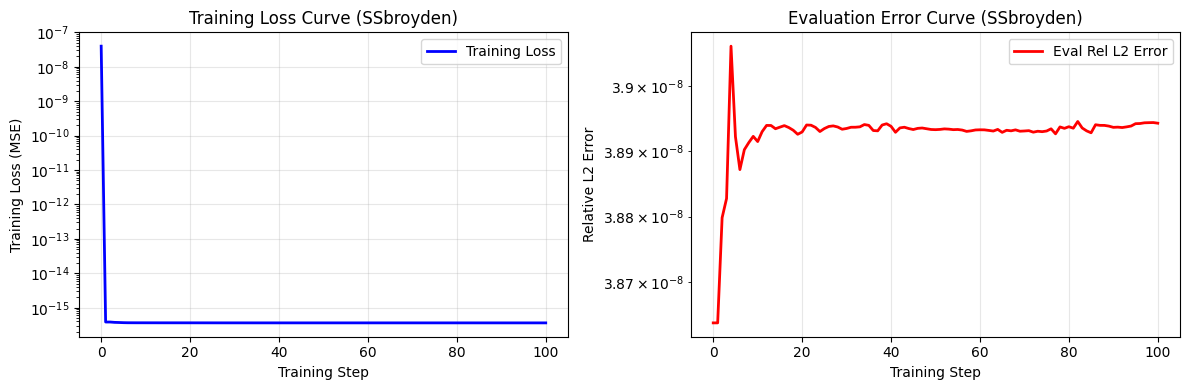

Final training loss: 3.625673e-16
Final eval rel L2 error: 3.894340e-08


In [9]:
# Plot training curves
def plot_training_curves(history, title_suffix=""):
    """Plot training loss and evaluation error curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Training loss
    ax1.semilogy(history['step_indices'], history['train_losses'], 'b-', linewidth=2, label='Training Loss')
    ax1.set_xlabel('Training Step')
    ax1.set_ylabel('Training Loss (MSE)')
    ax1.set_title(f'Training Loss Curve{title_suffix}')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Evaluation error  
    ax2.semilogy(history['step_indices'], history['eval_errors'], 'r-', linewidth=2, label='Eval Rel L2 Error')
    ax2.set_xlabel('Training Step')
    ax2.set_ylabel('Relative L2 Error')
    ax2.set_title(f'Evaluation Error Curve{title_suffix}')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print(f"Final training loss: {history['final_train_loss']:.6e}")
    print(f"Final eval rel L2 error: {history['final_eval_error']:.6e}")

# Plot the training curves
plot_training_curves(history, " (SSbroyden)")

In [10]:
# Example usage: Run experiment with Adam optimizer
model_adam, history_adam = run_experiment_adam(
    M=65, k=2, node_type="cheb",
    steps=1000, lr=1e-3, n_train=4000, n_eval=20000, log_every=1
)

step 999, train losses = 3.538e-09, eval rel L2=1.064e-04: 100%|██████████| 1000/1000 [00:31<00:00, 31.58it/s]


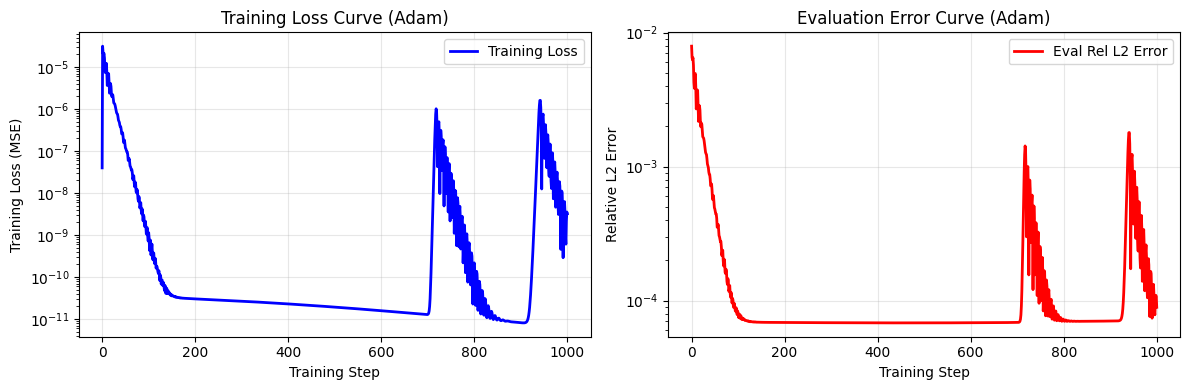

Final training loss: 3.217472e-09
Final eval rel L2 error: 8.910298e-05

Comparison of final results:
SSBroyden - Final eval rel L2 error: 3.894340e-08
Adam      - Final eval rel L2 error: 8.910298e-05


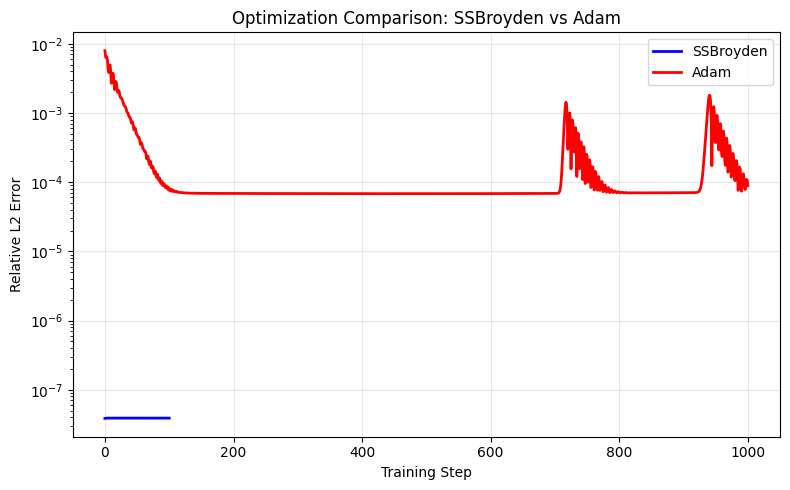

In [11]:
# Plot training curves for Adam
plot_training_curves(history_adam, " (Adam)")

# Compare final results
print(f"\nComparison of final results:")
print(f"SSBroyden - Final eval rel L2 error: {history['final_eval_error']:.6e}")
print(f"Adam      - Final eval rel L2 error: {history_adam['final_eval_error']:.6e}")

# Plot comparison of evaluation errors
plt.figure(figsize=(8, 5))
plt.semilogy(history['step_indices'], history['eval_errors'], 'b-', linewidth=2, label='SSBroyden')
plt.semilogy(history_adam['step_indices'], history_adam['eval_errors'], 'r-', linewidth=2, label='Adam')
plt.xlabel('Training Step')
plt.ylabel('Relative L2 Error')
plt.title('Optimization Comparison: SSBroyden vs Adam')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def run_experiment_adam_to_ssbroyden(
    M: int = 65,
    k: int = 3,
    node_type: str = "cheb",          # "cheb" or "uniform"
    # training
    adam_steps: int = 100,            # Number of Adam steps before switching
    ssbroyden_steps: int = 400,       # Number of SSBroyden steps after switching
    lr: float = 1e-3,                 # Adam learning rate
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),
    # logging
    log_every: int = 10,
):
    """
    Hybrid training function that starts with Adam optimizer for initial iterations,
    then switches to SSBroyden optimizer for fine-tuning.
    """
    
    # nodes
    xs_cheb = cheb_lobatto_nodes(M)
    ys_cheb = f_sin(xs_cheb, k)
    # magnitudes |a_j| for logits
    w0 = lobatto_bary_weights(M)

    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE)
    y_train = f_sin(x_train, k)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE)
    y_eval = f_sin(x_eval, k)

    # Initialize model with barycentric structure
    tau   = 1.0
    beta0 = jnp.log(jnp.abs(w0))       # β_j = log|w_j|
    gate  = SigmaGate(x_nodes=xs_cheb, w_signs=jnp.sign(w0), beta=50.0, mode="rational")
    core  = FixedLogKernelSoftmax(x_nodes=xs_cheb, yvals=ys_cheb, beta=beta0, tau=tau, delta=1e-14)
    model = SignedLogKernelSoftmax(core, gate, node_atol=1e-18)

    # Training history tracking
    train_losses = []
    eval_errors = []
    step_indices = []
    optimizer_labels = []  # Track which optimizer was used for each step


    
    # =================== PHASE 2: SSBROYDEN TRAINING ===================
    # Create SSBroyden optimizer - need to reinitialize with current model state
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))

        def f(params, x, y):
            node = nnx.merge(graphdef, base_state_pure)
            nnx.update(node, params)
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx_ssbroyden = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)
    optim_ssbroyden = nnx.Optimizer(model, tx_ssbroyden, wrt=nnx.Param)

    # Build the oracle from current model state
    graphdef, base_state = nnx.split(model)
    base_state = nnx.freeze(nnx.pure(base_state))
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_ssbroyden(model, opt, x, y):
        def cur_loss(m): 
            return loss_fn(m, x, y)
        
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # SSBroyden training loop
    pbar_ssbroyden = tqdm(range(ssbroyden_steps), desc="SSBroyden phase")
    for i in pbar_ssbroyden:
        current_step = adam_steps + i
        if i % log_every == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            eval_errors.append(float(eval_error))
            step_indices.append(current_step)
            optimizer_labels.append('SSBroyden')
            pbar_ssbroyden.set_description(f"SSBroyden step {i}, eval rel L2={eval_error:.3e}")

        loss = train_step_ssbroyden(model, optim_ssbroyden, x_train, y_train)

    print(f"Phase 1: Training with Adam for {adam_steps} steps...")
    
    # =================== PHASE 1: ADAM TRAINING ===================
    # Create Adam optimizer
    tx_adam = optax.adam(lr)
    optim_adam = nnx.Optimizer(model, tx_adam, wrt=nnx.Param)

    @nnx.jit
    def train_step_adam(model, opt, x, y):
        def cur_loss(m): 
            return loss_fn(m, x, y)
        
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)
        opt.update(model, grads)
        return f_k

    # Adam training loop
    pbar_adam = tqdm(range(adam_steps), desc="Adam phase")
    for i in pbar_adam:
        if i % log_every == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            eval_errors.append(float(eval_error))
            step_indices.append(i)
            optimizer_labels.append('Adam')
            pbar_adam.set_description(f"Adam step {i}, eval rel L2={eval_error:.3e}")

        loss = train_step_adam(model, optim_adam, x_train, y_train)

    print(f"Phase 1 complete. Switching to SSBroyden for {ssbroyden_steps} steps...")

    # Store final metrics
    final_loss = train_step_ssbroyden(model, optim_ssbroyden, x_train, y_train)
    final_eval_error = rel_l2_error(model, x_eval, y_eval)
    train_losses.append(float(final_loss))
    eval_errors.append(float(final_eval_error))
    step_indices.append(adam_steps + ssbroyden_steps)
    optimizer_labels.append('SSBroyden')
    
    # Convert to arrays for easier plotting
    train_losses = jnp.array(train_losses)
    eval_errors = jnp.array(eval_errors)
    step_indices = jnp.array(step_indices)
    
    print(f"Training complete! Final eval rel L2 error: {final_eval_error:.6e}")
    
    return model, {
        'train_losses': train_losses,
        'eval_errors': eval_errors,
        'step_indices': step_indices,
        'optimizer_labels': optimizer_labels,
        'adam_steps': adam_steps,
        'ssbroyden_steps': ssbroyden_steps,
        'final_train_loss': float(final_loss),
        'final_eval_error': float(final_eval_error),
        'switch_point': adam_steps
    }

In [27]:
# Example usage: Run hybrid Adam->SSBroyden training
print("Running hybrid Adam->SSBroyden training...")
model_hybrid, history_hybrid = run_experiment_adam_to_ssbroyden(
    M=65, k=2, 
    adam_steps=10000,           # Start with 1000 Adam steps
    ssbroyden_steps=200,      # Then 400 SSBroyden steps  
    lr=1e-7,
    n_train=4000, n_eval=20000, log_every=5
)

Running hybrid Adam->SSBroyden training...


SSBroyden step 195, eval rel L2=3.887e-08: 100%|██████████| 200/200 [00:04<00:00, 40.13it/s]


Phase 1: Training with Adam for 10000 steps...


Adam step 3555, eval rel L2=5.159e-08:  36%|███▌      | 3560/10000 [00:31<00:57, 111.68it/s]


KeyboardInterrupt: 

In [21]:
# Plot the hybrid training results
def plot_hybrid_training_curves(history, title_suffix=""):
    """Plot training curves for hybrid Adam->SSBroyden training with switch point marked."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Split data by optimizer
    adam_mask = [label == 'Adam' for label in history['optimizer_labels']]
    ssbroyden_mask = [label == 'SSBroyden' for label in history['optimizer_labels']]
    
    adam_steps = [history['step_indices'][i] for i, mask in enumerate(adam_mask) if mask]
    adam_errors = [history['eval_errors'][i] for i, mask in enumerate(adam_mask) if mask]
    
    ssbroyden_steps = [history['step_indices'][i] for i, mask in enumerate(ssbroyden_mask) if mask]
    ssbroyden_errors = [history['eval_errors'][i] for i, mask in enumerate(ssbroyden_mask) if mask]
    
    # Plot evaluation error curves
    if adam_steps:
        ax.semilogy(adam_steps, adam_errors, 'b-', linewidth=2, label='Adam Phase', marker='o', markersize=3)
    if ssbroyden_steps:
        ax.semilogy(ssbroyden_steps, ssbroyden_errors, 'r-', linewidth=2, label='SSBroyden Phase', marker='s', markersize=3)
    
    # Mark the switch point
    switch_point = history['switch_point']
    ax.axvline(x=switch_point, color='gray', linestyle='--', alpha=0.7, label=f'Switch Point (step {switch_point})')
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Relative L2 Error')
    ax.set_title(f'Hybrid Training: Adam → SSBroyden{title_suffix}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"Training Summary:")
    print(f"Adam phase: {history['adam_steps']} steps")
    print(f"SSBroyden phase: {history['ssbroyden_steps']} steps")
    print(f"Total steps: {history['adam_steps'] + history['ssbroyden_steps']}")
    print(f"Final eval rel L2 error: {history['final_eval_error']:.6e}")



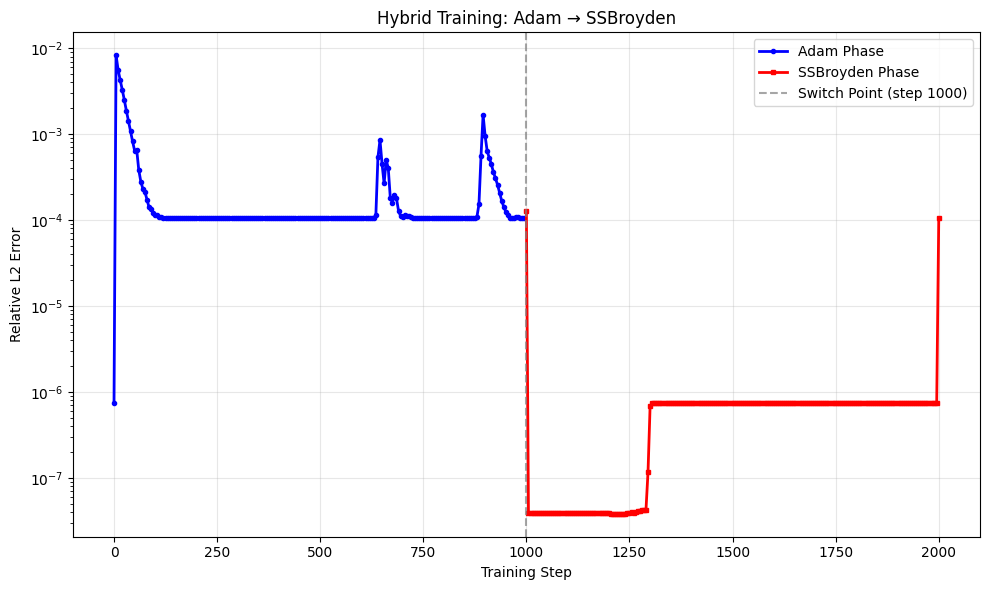

Training Summary:
Adam phase: 1000 steps
SSBroyden phase: 1000 steps
Total steps: 2000
Final eval rel L2 error: 1.053428e-04


In [22]:
plot_hybrid_training_curves(history_hybrid)